In [ ]:
# ============================================================
# CELLULE 1 — Uploadés les fichiers
# ============================================================

import os

FICHIERS_ATTENDUS = ['regression_nonlinear.csv']

print("📂 Contenu de /content :")
for f in sorted(os.listdir('/content')):
    print("   -", f)

print("\n🔎 Vérification :")
manquants = []
for f in FICHIERS_ATTENDUS:
    chemin = f'/content/{f}'
    if os.path.exists(chemin):
        taille_ko = os.path.getsize(chemin) / 1024
        print(f"   ✅ {f}  ({taille_ko:.1f} Ko)")
    else:
        print(f"   ❌ {f}  MANQUANT")
        manquants.append(f)

if manquants:
    print("\n⚠️  Fichiers manquants :", manquants)
    print("   → Upload-les via le bouton 📁 Fichiers → ⬆️ Upload")
else:
    print("\n🎉 Tous les fichiers sont prêts. Tu peux passer à la cellule 2.")

📂 Contenu de /content :
   - .config
   - figs
   - figs_exo1.zip
   - regression_nonlinear.csv
   - resultats_nonlinear_exo1.csv
   - sample_data

🔎 Vérification :
   ✅ regression_nonlinear.csv  (14.3 Ko)

🎉 Tous les fichiers sont prêts. Tu peux passer à la cellule 2.


In [ ]:
# Cellule 2 : imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# --- Métriques ---
def mse(y, yh):  return np.mean((y - yh) ** 2)
def rmse(y, yh): return np.sqrt(mse(y, yh))
def mae(y, yh):  return np.mean(np.abs(y - yh))
def r2_manual(y, yh):
    ss_res = np.sum((y - yh) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

In [ ]:
# Cellule 3 : chargement + standardisation
def load_and_prepare(path):
    df = pd.read_csv(path)
    y_col, split_col = 'y', 'split'
    feat_cols = [c for c in df.columns if c not in (y_col, split_col)]

    tr = df[df[split_col] == 'train']
    va = df[df[split_col] == 'val']
    te = df[df[split_col] == 'test']

    Xtr = tr[feat_cols].values.astype(np.float64)
    Xva = va[feat_cols].values.astype(np.float64)
    Xte = te[feat_cols].values.astype(np.float64)
    ytr = tr[y_col].values.astype(np.float64)
    yva = va[y_col].values.astype(np.float64)
    yte = te[y_col].values.astype(np.float64)

    mu = Xtr.mean(axis=0); sd = Xtr.std(axis=0); sd[sd == 0] = 1.0
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    ym = ytr.mean(); ys = ytr.std() or 1.0
    ytr_s = (ytr - ym) / ys
    yva_s = (yva - ym) / ys
    yte_s = (yte - ym) / ys

    return dict(Xtr=Xtr, Xva=Xva, Xte=Xte,
                ytr=ytr, yva=yva, yte=yte,
                ytr_s=ytr_s, yva_s=yva_s, yte_s=yte_s,
                ym=ym, ys=ys, mu=mu, sd=sd,
                feat_cols=feat_cols,
                n_tr=len(ytr), n_va=len(yva), n_te=len(yte), d=Xtr.shape[1])

In [ ]:
# Cellule 4 : modèles
class LinearRidge:
    def __init__(self, X, y, lam=0.0):
        self.n, self.d_orig = X.shape
        self.X = np.hstack([np.ones((self.n, 1)), X])
        self.y = y
        self.lam = lam
        self.P = np.eye(self.d_orig + 1); self.P[0, 0] = 0.0
        self.dim = self.d_orig + 1
        self.H = self.X.T @ self.X / self.n + lam * self.P

    def loss(self, w):
        r = self.X @ w - self.y
        return 0.5 * np.mean(r ** 2) + 0.5 * self.lam * (w @ self.P @ w)

    def grad(self, w):
        r = self.X @ w - self.y
        return self.X.T @ r / self.n + self.lam * self.P @ w

    def predict(self, X, w):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        return Xb @ w

    def direct_solution(self):
        return np.linalg.solve(self.H, self.X.T @ self.y / self.n)


class KernelRidge:
    def __init__(self, X, y, sigma=1.0, lam=0.0):
        self.X = X; self.y = y
        self.n = X.shape[0]
        self.sigma = sigma; self.lam = lam
        self.dim = self.n
        self.K = self._kernel(X, X)
        self.H = self.K @ self.K / self.n + lam * self.K

    def _kernel(self, A, B):
        aa = np.sum(A**2, 1)[:, None]
        bb = np.sum(B**2, 1)[None, :]
        d2 = np.maximum(aa + bb - 2 * A @ B.T, 0)
        return np.exp(-d2 / (2 * self.sigma ** 2))

    def loss(self, a):
        r = self.K @ a - self.y
        return 0.5 * np.mean(r ** 2) + 0.5 * self.lam * (a @ self.K @ a)

    def grad(self, a):
        r = self.K @ a - self.y
        return self.K @ r / self.n + self.lam * self.K @ a

    def predict(self, X, a):
        return self._kernel(X, self.X) @ a

    def direct_solution(self):
        return np.linalg.solve(self.K + self.n * self.lam * np.eye(self.n), self.y)


def batch_grad(model, theta, idx):
    if isinstance(model, LinearRidge):
        Xb = model.X[idx]; yb = model.y[idx]
        return Xb.T @ (Xb @ theta - yb) / len(idx) + model.lam * model.P @ theta
    else:
        Kb = model.K[idx]; yb = model.y[idx]
        return Kb.T @ (Kb @ theta - yb) / len(idx) + model.lam * model.K @ theta

In [ ]:
# Cellule 5 : optimiseurs
METHODS = ['gd', 'gd_ls', 'sgd', 'momentum', 'adagrad', 'rmsprop', 'adam']
STOCHASTIC = ['sgd', 'momentum', 'adagrad', 'rmsprop', 'adam']

def optimize(model, method, eta, n_epochs, batch_size=32,
             mu=0.9, rho=0.9, beta1=0.9, beta2=0.999, eps=1e-8, seed=42):
    rng = np.random.default_rng(seed)
    theta = np.zeros(model.dim)
    v = np.zeros_like(theta); s = np.zeros_like(theta); m = np.zeros_like(theta)
    n_grad = n_loss = n_updates = 0
    loss_hist = []; n = model.n; t = 0

    for ep in range(n_epochs):
        if method in ('gd', 'gd_ls'):
            g = model.grad(theta); n_grad += 1
            if method == 'gd':
                theta = theta - eta * g
            else:
                denom = g @ model.H @ g
                eta_t = (g @ g) / denom if denom > 0 else eta
                theta = theta - eta_t * g
            n_updates += 1; t += 1
        else:
            idx = rng.permutation(n)
            for b in range(0, n, batch_size):
                bidx = idx[b:b + batch_size]
                g = batch_grad(model, theta, bidx); n_grad += 1
                if method == 'sgd':
                    theta = theta - eta * g
                elif method == 'momentum':
                    v = mu * v + g
                    theta = theta - eta * v
                elif method == 'adagrad':
                    s = s + g ** 2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'rmsprop':
                    s = rho * s + (1 - rho) * g ** 2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'adam':
                    m = beta1 * m + (1 - beta1) * g
                    s = beta2 * s + (1 - beta2) * g ** 2
                    mh = m / (1 - beta1 ** (t + 1))
                    sh = s / (1 - beta2 ** (t + 1))
                    theta = theta - eta * mh / (np.sqrt(sh) + eps)
                n_updates += 1; t += 1
        loss_hist.append(model.loss(theta)); n_loss += 1

    return theta, np.array(loss_hist), n_grad, n_loss, n_updates

In [ ]:
# Cellule 6 : différences finies centrées
def check_gradient(model, seed=42, n_check=5, h=1e-5):
    rng = np.random.default_rng(seed)
    theta = rng.normal(0, 0.1, model.dim)
    g = model.grad(theta)
    idxs = rng.choice(model.dim, size=min(n_check, model.dim), replace=False)
    errs = []
    for i in idxs:
        tp = theta.copy(); tp[i] += h
        tm = theta.copy(); tm[i] -= h
        num = (model.loss(tp) - model.loss(tm)) / (2 * h)
        den = max(abs(num), abs(g[i]), 1e-12)
        errs.append(abs(num - g[i]) / den)
    return errs

In [ ]:
# Cellule 7 : pipeline train + sélection de η
def train_one(model, method, eta, n_epochs, batch_size, seed,
              X_val, y_val_s, X_test, y_test, y_mu, y_sigma):
    t0 = time.time()
    theta, loss_hist, n_grad, n_loss, n_up = optimize(
        model, method, eta, n_epochs, batch_size, seed=seed)
    elapsed = time.time() - t0

    val_pred_s = model.predict(X_val, theta)
    val_loss = 0.5 * np.mean((val_pred_s - y_val_s) ** 2)
    y_val_pred = val_pred_s * y_sigma + y_mu
    y_test_pred = model.predict(X_test, theta) * y_sigma + y_mu

    return dict(theta=theta, loss_hist=loss_hist, val_loss=val_loss,
                best_ep=int(np.argmin(loss_hist)),
                y_val_pred=y_val_pred, y_test_pred=y_test_pred,
                time=elapsed, n_grad=n_grad, n_loss=n_loss, n_updates=n_up)


def search_and_eval(data, model_kind, method, eta_grid, n_epochs, batch_size, seeds):
    Xtr, ytr_s = data['Xtr'], data['ytr_s']
    Xva, yva_s = data['Xva'], data['yva_s']
    Xte, yte = data['Xte'], data['yte']
    ym, ys = data['ym'], data['ys']

    results_per_eta = []
    for eta in eta_grid:
        val_losses = []
        for seed in seeds:
            m = (LinearRidge(Xtr, ytr_s, lam=data['lam'])
                 if model_kind == 'linear'
                 else KernelRidge(Xtr, ytr_s, sigma=data['sigma'], lam=data['lam']))
            r = train_one(m, method, eta, n_epochs, batch_size, seed,
                          Xva, yva_s, Xte, yte, ym, ys)
            val_losses.append(r['val_loss'])
        results_per_eta.append((eta, np.mean(val_losses)))

    best_eta = min(results_per_eta, key=lambda x: x[1])[0]

    metrics = {k: [] for k in ['rmse_v','mse_t','rmse_t','mae_t','r2_t',
                                'time','n_grad','n_loss','n_up','best_ep']}
    curves, preds = [], []
    for seed in seeds:
        m = (LinearRidge(Xtr, ytr_s, lam=data['lam'])
             if model_kind == 'linear'
             else KernelRidge(Xtr, ytr_s, sigma=data['sigma'], lam=data['lam']))
        r = train_one(m, method, best_eta, n_epochs, batch_size, seed,
                      Xva, yva_s, Xte, yte, ym, ys)
        yv, yt = data['yva'], data['yte']
        metrics['rmse_v'].append(rmse(yv, r['y_val_pred']))
        metrics['mse_t'].append(mse(yt, r['y_test_pred']))
        metrics['rmse_t'].append(rmse(yt, r['y_test_pred']))
        metrics['mae_t'].append(mae(yt, r['y_test_pred']))
        metrics['r2_t'].append(r2_manual(yt, r['y_test_pred']))
        metrics['time'].append(r['time'])
        metrics['n_grad'].append(r['n_grad'])
        metrics['n_loss'].append(r['n_loss'])
        metrics['n_up'].append(r['n_updates'])
        metrics['best_ep'].append(r['best_ep'])
        curves.append(r['loss_hist'])
        preds.append(r['y_test_pred'])

    return dict(best_eta=best_eta, metrics=metrics,
                curves=curves, preds=preds, eta_scan=results_per_eta)

In [ ]:
# ============================================================
# CELLULE 8 (VERSION FINALE CORRIGÉE) — Figures
# ============================================================

# Couleurs fixes par méthode (cohérence entre toutes les figures)
COLORS = {
    'gd':       'tab:blue',
    'gd_ls':    'tab:orange',
    'sgd':      'tab:green',
    'momentum': 'tab:red',
    'adagrad':  'tab:purple',
    'rmsprop':  'tab:brown',
    'adam':     'tab:pink',
}


def plot_results(name, data, results_linear, results_kernel, outdir='figs'):
    """4 sous-figures : perte train, prédit/réel, résidus, sélection de η."""
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    yt = data['yte']

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # ---------------- (a) Perte train vs époques ----------------
    for method in METHODS:
        if method in results_linear:
            c = results_linear[method]['curves'][0]
            axes[0, 0].plot(c, label=method, color=COLORS[method])
    axes[0, 0].set_xlabel('Époque')
    axes[0, 0].set_ylabel('Perte (train)')
    axes[0, 0].set_title(f'{name} — perte train (linéaire, moyenne 3 graines)\n'
                         'perte évaluée après chaque époque')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # ---------------- (b) Prédit vs réel (test, noyau) ----------------
    best = min(results_kernel,
               key=lambda m: np.mean(results_kernel[m]['metrics']['rmse_t']))
    yp = results_kernel[best]['preds'][0]
    axes[0, 1].scatter(yt, yp, s=18, alpha=0.7, edgecolor='k', linewidth=0.3)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    axes[0, 1].plot(lim, lim, 'r--', label='diagonale')
    axes[0, 1].set_xlabel('y réel')
    axes[0, 1].set_ylabel('ŷ')
    axes[0, 1].set_title(f'{name} — test (noyau RBF, {best})')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)

    # ---------------- (c) Histogramme des résidus ----------------
    axes[1, 0].hist(yt - yp, bins=25, edgecolor='k', alpha=0.8)
    axes[1, 0].axvline(0, color='r', linestyle='--', label='zéro')
    axes[1, 0].set_xlabel('résidu (y − ŷ)')
    axes[1, 0].set_ylabel('fréquence')
    axes[1, 0].set_title(f'Histogramme des résidus (test, noyau RBF, {best})')
    axes[1, 0].legend(fontsize=8)

    # ---------------- (d) Sélection de η (avec minimum marqué) ----------------
    for method in METHODS:
        if method in results_linear:
            scan = results_linear[method]['eta_scan']
            etas = [s[0] for s in scan]
            vals = [s[1] for s in scan]
            axes[1, 1].plot(etas, vals, 'o-',
                            label=method, color=COLORS[method])
            # Étoile ★ sur le η optimal (exclue de la légende)
            i_best = int(np.argmin(vals))
            axes[1, 1].plot(etas[i_best], vals[i_best], '*',
                            markersize=14, markeredgecolor='k',
                            markerfacecolor='gold', zorder=5,
                            label='_nolegend_')      # ← exclu de la légende

    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_xlabel('η')
    axes[1, 1].set_ylabel('Perte validation')
    axes[1, 1].set_title('Sélection de η (validation, moyenne 3 graines)\n'
                         '★ = η retenu')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    fig.suptitle(f'{name} — Exercice 1 : régression',
                 fontsize=14, y=1.00)
    plt.tight_layout()
    plt.savefig(f'{outdir}/{name}_exo1.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_nonlinear_2d(data, results, outdir='figs'):
    """Fonction cible et prédictions en 2D (avec colorbars)."""
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    Xte = data['Xte']
    yte = data['yte']

    best = min(results, key=lambda m: np.mean(results[m]['metrics']['rmse_t']))
    yp = results[best]['preds'][0]

    # Plage de couleurs commune (pour comparaison directe)
    vmin = min(yte.min(), yp.min())
    vmax = max(yte.max(), yp.max())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ---------------- (a) y réel ----------------
    sc0 = axes[0].scatter(Xte[:, 0], Xte[:, 1], c=yte,
                          s=25, cmap='viridis', edgecolor='k', linewidth=0.3,
                          vmin=vmin, vmax=vmax)
    axes[0].set_title('y réel (test)')
    axes[0].set_xlabel('x₁')
    axes[0].set_ylabel('x₂')
    plt.colorbar(sc0, ax=axes[0], label='y')

    # ---------------- (b) y prédit ----------------
    sc1 = axes[1].scatter(Xte[:, 0], Xte[:, 1], c=yp,
                          s=25, cmap='viridis', edgecolor='k', linewidth=0.3,
                          vmin=vmin, vmax=vmax)
    axes[1].set_title(f'ŷ (noyau RBF, {best})')
    axes[1].set_xlabel('x₁')
    axes[1].set_ylabel('x₂')
    plt.colorbar(sc1, ax=axes[1], label='ŷ')

    # ---------------- (c) Prédit vs réel ----------------
    axes[2].scatter(yte, yp, s=25, alpha=0.75, edgecolor='k', linewidth=0.3)
    lim = [min(yte.min(), yp.min()), max(yte.max(), yp.max())]
    axes[2].plot(lim, lim, 'r--', label='diagonale')
    axes[2].set_xlabel('y réel')
    axes[2].set_ylabel('ŷ')
    axes[2].set_title('ŷ vs y (test)')
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(
        f'Nonlinear — fonction cible et prédiction '
        f'(noyau RBF, {best}, moyenne 3 graines)',
        fontsize=13, y=1.02)

    plt.tight_layout()
    plt.savefig(f'{outdir}/nonlinear_2d.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_loss_vs_updates(results_linear, results_kernel, name, outdir='figs'):
    """Perte vs nombre de mises à jour (comparaison équitable GD vs SGD)."""
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, results, label in zip(
            axes,
            [results_linear, results_kernel],
            ['linéaire', 'noyau RBF']):
        for method in METHODS:
            if method in results:
                r = results[method]
                n_up = np.mean(r['metrics']['n_up'])
                curve = r['curves'][0]
                x = np.linspace(0, n_up, len(curve))
                ax.plot(x, curve, label=method, color=COLORS[method])
        ax.set_xlabel('Nombre de mises à jour')
        ax.set_ylabel('Perte (train)')
        ax.set_title(f'{name} — {label} (perte vs mises à jour)')
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle('Comparaison équitable GD vs SGD (budget de calcul égal)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{outdir}/{name}_loss_vs_updates.png', dpi=130,
                bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# Cellule 9 : run_experiment
def run_experiment(csv_path, name, n_epochs=200, batch_size=32,
                   lam_grid=(0.0, 1e-3, 1e-2, 1e-1, 1.0),
                   sigma_grid=(0.1, 0.5, 1.0, 2.0, 5.0),
                   eta_grid=(1e-3, 1e-2, 5e-2, 1e-1, 5e-1),
                   seeds=(42, 123, 2024)):

    print(f"\n===== {name} =====")
    data = load_and_prepare(csv_path)
    print(f"n_train={data['n_tr']}, n_val={data['n_va']}, n_test={data['n_te']}, d={data['d']}")

    # Vérif gradients
    m_lin = LinearRidge(data['Xtr'], data['ytr_s'], lam=0.1)
    print("  Vérif grad linéaire   :", ['%.2e'%e for e in check_gradient(m_lin)])
    m_ker = KernelRidge(data['Xtr'], data['ytr_s'], sigma=1.0, lam=0.1)
    print("  Vérif grad noyau RBF :", ['%.2e'%e for e in check_gradient(m_ker)])

    # Scan σ et λ (noyau)
    best_sigma, best_lam_k, best_vl = None, None, np.inf
    for sigma in sigma_grid:
        for lam in lam_grid[1:]:
            mm = KernelRidge(data['Xtr'], data['ytr_s'], sigma=sigma, lam=lam)
            a = mm.direct_solution()
            vl = 0.5 * np.mean((mm.predict(data['Xva'], a) - data['yva_s'])**2)
            if vl < best_vl:
                best_vl, best_sigma, best_lam_k = vl, sigma, lam
    print(f"  Noyau : σ*={best_sigma}, λ*={best_lam_k} (val={best_vl:.4e})")

    # Scan λ (linéaire)
    best_lam_l, best_vl_l = None, np.inf
    for lam in lam_grid:
        mm = LinearRidge(data['Xtr'], data['ytr_s'], lam=lam)
        w = mm.direct_solution()
        vl = 0.5 * np.mean((mm.predict(data['Xva'], w) - data['yva_s'])**2)
        if vl < best_vl_l:
            best_vl_l, best_lam_l = vl, lam
    print(f"  Linéaire : λ*={best_lam_l} (val={best_vl_l:.4e})")

    data_lin = dict(data, lam=best_lam_l)
    data_ker = dict(data, lam=best_lam_k, sigma=best_sigma)

    results_linear, results_kernel = {}, {}
    for method in METHODS:
        print(f"  >> {method} (linéaire)")
        results_linear[method] = search_and_eval(
            data_lin, 'linear', method, eta_grid, n_epochs, batch_size, seeds)
        print(f"     η* = {results_linear[method]['best_eta']}")

        print(f"  >> {method} (noyau RBF)")
        results_kernel[method] = search_and_eval(
            data_ker, 'kernel', method, eta_grid, n_epochs, batch_size, seeds)
        print(f"     η* = {results_kernel[method]['best_eta']}")

    def summarize(results, model_name):
        rows = []
        for method in METHODS:
            r = results[method]; m = r['metrics']
            rows.append(dict(
                méthode=method, modèle=model_name, η=r['best_eta'],
                époque_best=np.mean(m['best_ep']),
                RMSE_val=np.mean(m['rmse_v']),
                MSE_test=np.mean(m['mse_t']),
                RMSE_test=np.mean(m['rmse_t']),
                MAE_test=np.mean(m['mae_t']),
                R2_test=np.mean(m['r2_t']),
                temps_s=np.mean(m['time']),
                appels_grad=int(np.mean(m['n_grad'])),
                mises_à_jour=int(np.mean(m['n_up'])),
            ))
        return pd.DataFrame(rows)

    df_lin = summarize(results_linear, 'linéaire')
    df_ker = summarize(results_kernel, 'noyau RBF')
    df_all = pd.concat([df_lin, df_ker], ignore_index=True)
    print("\n" + df_all.to_string(index=False))
    df_all.to_csv(f'resultats_{name}_exo1.csv', index=False)

    plot_results(name, data, results_linear, results_kernel)
    if name == 'nonlinear':
        plot_nonlinear_2d(data, results_kernel)

    return df_all


===== nonlinear =====
n_train=216, n_val=72, n_test=72, d=2
  Vérif grad linéaire   : ['6.49e-11', '3.30e-12', '1.20e-10']
  Vérif grad noyau RBF : ['2.84e-11', '6.21e-11', '2.49e-11', '1.45e-11', '1.34e-11']
  Noyau : σ*=0.5, λ*=0.001 (val=2.8820e-02)
  Linéaire : λ*=0.1 (val=4.7049e-01)
  >> gd (linéaire)
     η* = 0.01
  >> gd (noyau RBF)
     η* = 0.5
  >> gd_ls (linéaire)
     η* = 0.001
  >> gd_ls (noyau RBF)
     η* = 0.001
  >> sgd (linéaire)
     η* = 0.001
  >> sgd (noyau RBF)
     η* = 0.5
  >> momentum (linéaire)
     η* = 0.05
  >> momentum (noyau RBF)
     η* = 0.1
  >> adagrad (linéaire)
     η* = 0.01
  >> adagrad (noyau RBF)
     η* = 0.5
  >> rmsprop (linéaire)
     η* = 0.001
  >> rmsprop (noyau RBF)
     η* = 0.01
  >> adam (linéaire)
     η* = 0.05
  >> adam (noyau RBF)
     η* = 0.01

 méthode    modèle     η  époque_best  RMSE_val  MSE_test  RMSE_test  MAE_test   R2_test  temps_s  appels_grad  mises_à_jour
      gd  linéaire 0.010   199.000000  0.732348  0.67345

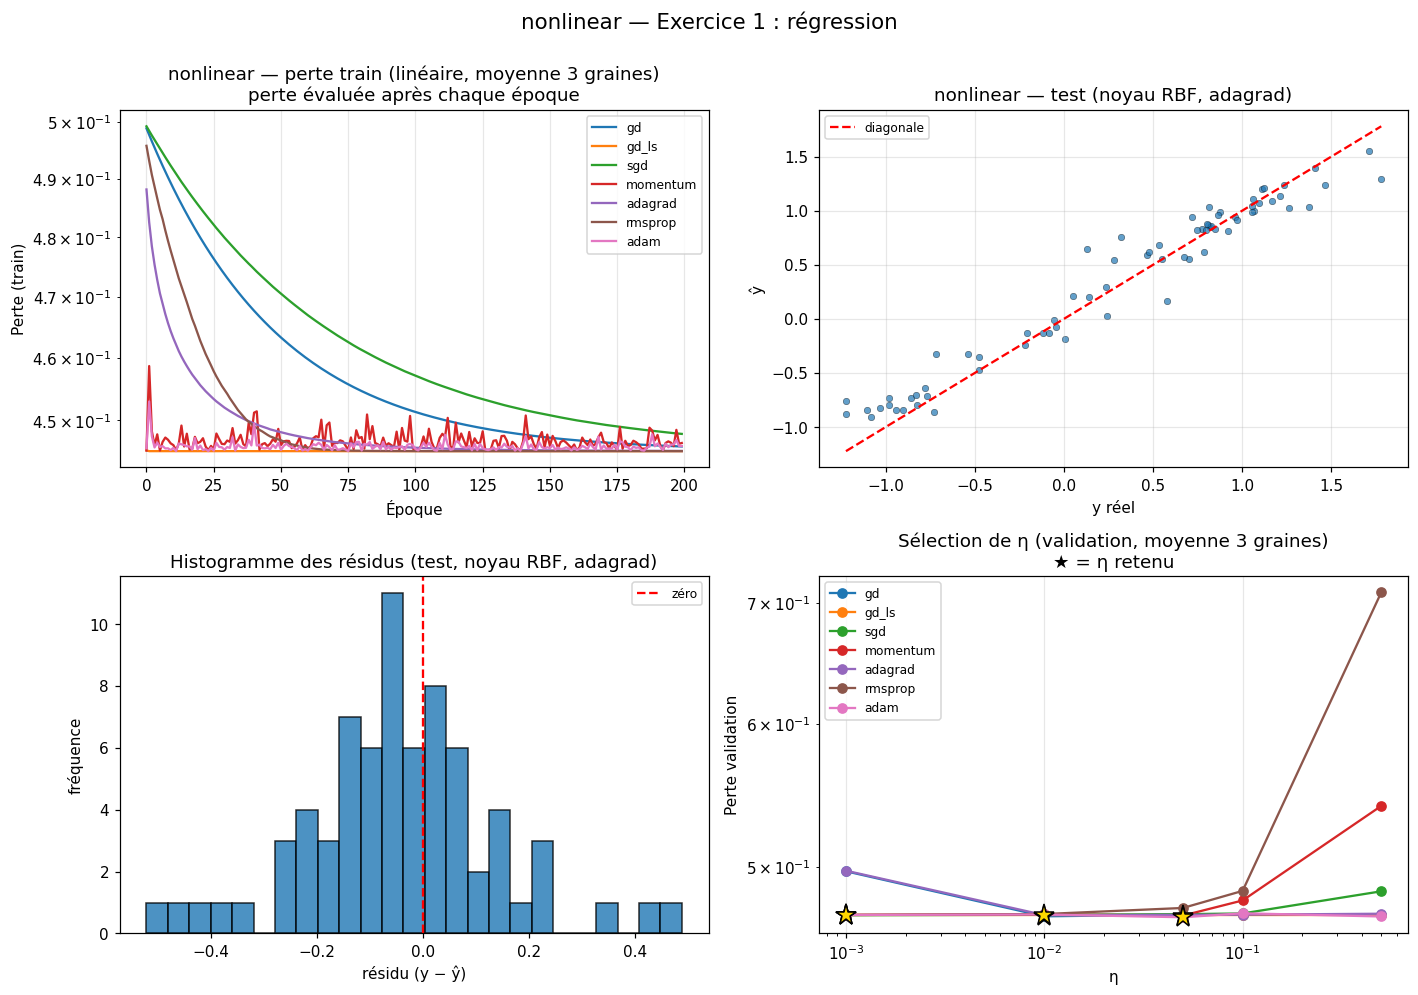

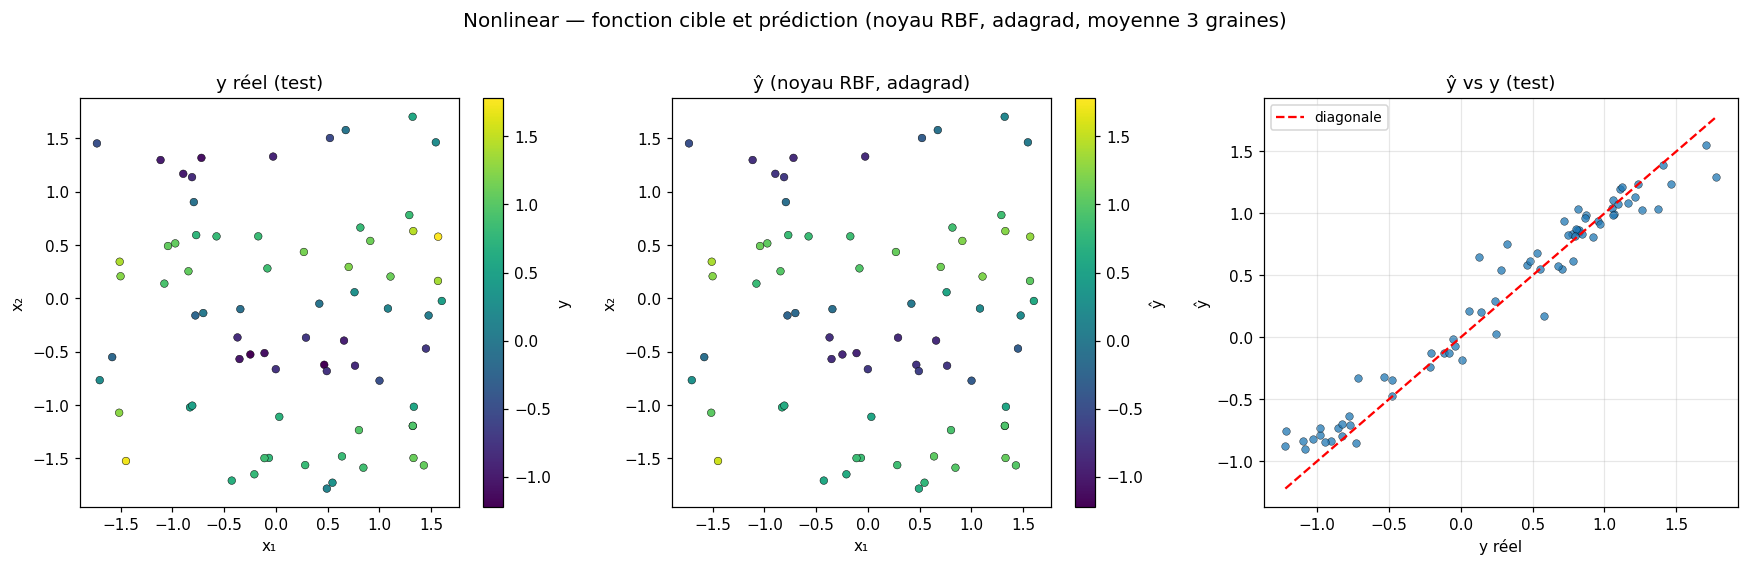

In [ ]:
df_nonlinear = run_experiment('regression_nonlinear.csv', 'nonlinear',
                               n_epochs=200, batch_size=32)

In [ ]:
# Cellule 12 : télécharger les CSV et figures
from google.colab import files
import shutil

files.download('resultats_nonlinear_exo1.csv')

# Zipper les figures
shutil.make_archive('figs_exo1', 'zip', 'figs')
files.download('figs_exo1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>